learning Neural network NN

In [ ]:
import numpy as np
import math

# --- 1. Threshold (Step) Function ---
def step_function(x, threshold=0.0):
    """
    Implements the Threshold or Step function.
    Output is 1 if input (x) exceeds the threshold, 0 otherwise.
    This function is non-differentiable at the threshold, making it unsuitable for backpropagation.
    """
    return np.where(x >= threshold, 1, 0)

# --- 2. Sigmoid Function ---
def sigmoid(x):
    """
    Implements the Sigmoid activation function.
    Range: (0, 1). Useful for binary classification output (probabilities).
    """
    # Using np.exp for element-wise exponentiation in the array
    return 1 / (1 + np.exp(-x))

# --- 3. Tanh (Hyperbolic Tangent) Function ---
def tanh_function(x):
    """
    Implements the Tanh activation function.
    Range: (-1, 1). Zero-centered, often performs better than Sigmoid in hidden layers.
    """
    return np.tanh(x)

# --- 4. ReLU (Rectified Linear Unit) Function ---
def relu(x):
    """
    Implements the ReLU activation function.
    Output is max(0, x). Most commonly used default activation in deep learning.
    """
    return np.maximum(0, x)

# --- 5. Leaky ReLU Function ---
def leaky_relu(x, alpha=0.01):
    """
    Implements the Leaky ReLU function.
    Returns x for x > 0, and (alpha * x) for x <= 0, preventing 'dying neurons'.
    """
    return np.where(x > 0, x, alpha * x)

# --- 6. Softmax Function ---
def softmax(x):
    """
    Implements the Softmax function.
    Used in the output layer for multi-class classification. Converts scores (logits)
    into a probability distribution that sums to 1.
    """
    # Subtracting the maximum input for numerical stability (common practice)
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x, axis=0) # Sum across the entire array for 1D input

# --- Demonstration ---

# Define a sample input array representing the weighted sum of inputs (or 'logits')
input_data = np.array([-2.0, 0.0, 3.0])

print(f"--- Input Data: {input_data} ---")

print(f"1. Step Function (Threshold=0): {step_function(input_data)}")
print(f"2. Sigmoid (Range 0 to 1):      {sigmoid(input_data)}")
print(f"3. Tanh (Range -1 to 1):        {tanh_function(input_data)}")
print(f"4. ReLU (max(0, x)):            {relu(input_data)}")
print(f"5. Leaky ReLU (alpha=0.01):     {leaky_relu(input_data)}")
print(f"6. Softmax (Probabilities sum to 1): {softmax(input_data)}")
print(f"   (Sum of Softmax outputs: {np.sum(softmax(input_data)):.4f})")


--- Input Data: [-2.  0.  3.] ---
1. Step Function (Threshold=0): [0 1 1]
2. Sigmoid (Range 0 to 1):      [0.11920292 0.5        0.95257413]
3. Tanh (Range -1 to 1):        [-0.96402758  0.          0.99505475]
4. ReLU (max(0, x)):            [0. 0. 3.]
5. Leaky ReLU (alpha=0.01):     [-0.02  0.    3.  ]
6. Softmax (Probabilities sum to 1): [0.00637746 0.04712342 0.94649912]
   (Sum of Softmax outputs: 1.0000)


Exercise for Neural Network for functions

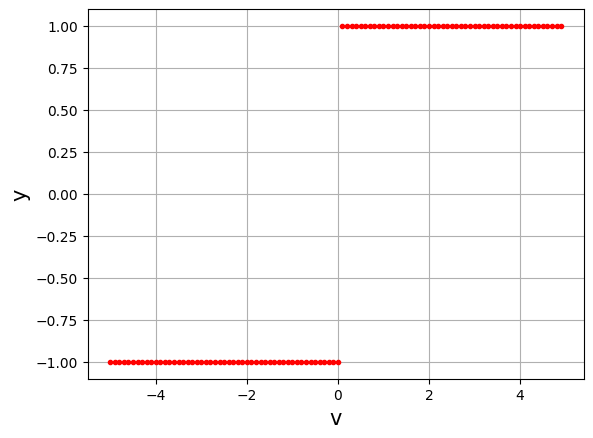

In [ ]:
import torch
import matplotlib.pyplot as plt

# Define the input tensor
x= torch.arange(-5,5,0.1)

y1= torch.sign(x)

plt.plot(x,y1,'r.',linewidth=2)

plt.grid('minor')

plt.xlabel('v',fontsize=15)

plt.ylabel('y',fontsize=15)

plt.show()

Linear Regression sampel

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score # New Import

# --- 1. Generate Synthetic Data ---
# We create data that already has a linear relationship: y = 2*x + 5 + (some noise)
# X must be reshaped to (n_samples, n_features) for scikit-learn
X = np.arange(100).reshape(-1, 1) # Features (Input: 0 to 99)
y = 2 * X.flatten() + 5 + np.random.normal(0, 10, 100) # Target (Output)

# Split the data into training and testing sets
# X_test and y_test are held back for validation/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- 2. Initialize and Train the Model ---

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
# The .fit() method is where the model calculates the optimal W (weight) and b (bias)
print("Training the Linear Regression model...")
model.fit(X_train, y_train)


# --- 3. Analyze Results, Validate, and Predict ---

# 1. Print the learned parameters
print("\n--- Learned Parameters ---")
# The coefficient (coef_) is the Weight (W) or slope
print(f"Weight (Slope, W): {model.coef_[0]:.4f}")
# The intercept (intercept_) is the Bias (b) or y-intercept
print(f"Bias (Y-Intercept, b): {model.intercept_:.4f}")
# Our initial data was generated with W=2 and b=5. The model's findings are close!


# 2. Model Validation (Evaluation on Test Set)
# Use the trained model to predict values for the unseen test data
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) # Alternatively, use model.score(X_test, y_test)

print("\n--- Model Validation (Evaluation on Test Set) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")
print("R2 close to 1.0 indicates a very good fit to the data.")


# 3. Make a single prediction on a new input
new_input = np.array([[105]]) # Predict the value for X=105
predicted_y = model.predict(new_input)

print("\n--- Single Point Prediction ---")
print(f"For an input X = 105, the predicted Y is: {predicted_y[0]:.4f}")


Training the Linear Regression model...

--- Learned Parameters ---
Weight (Slope, W): 2.0267
Bias (Y-Intercept, b): 4.9133

--- Model Validation (Evaluation on Test Set) ---
Mean Squared Error (MSE): 78.89
R-squared Score (R2): 0.9754
R2 close to 1.0 indicates a very good fit to the data.

--- Single Point Prediction ---
For an input X = 105, the predicted Y is: 217.7213


Gradient descent implementation

In [ ]:
import numpy as np

# --- 1. Generate Synthetic Data ---
# True parameters are W_true=2 and b_true=1
W_true = 2.0
b_true = 1.0
m = 50 # Number of data points

# Generate random X values
X = np.random.rand(m, 1) * 10
# Generate Y values with noise
y = W_true * X + b_true + np.random.normal(0, 1, (m, 1))


# --- 2. Hyperparameters and Initialization ---
# Learning Rate (alpha) - Controls the step size
learning_rate = 0.01
# Number of iterations (epochs)
iterations = 1000

# Initialize W and b with small random values (the "starting point" on the hill)
W = np.random.randn(1, 1)
b = np.random.randn(1)


# --- 3. Gradient Descent Functions ---

def compute_loss(X, y, W, b):
    """Calculates the Mean Squared Error (MSE) loss."""
    m = len(y)
    # Predicted value (y_hat = Wx + b)
    y_pred = X @ W + b
    # Squared error term
    error = y_pred - y
    # MSE Cost Function J(W, b)
    # np.sum returns a single scalar value (no index needed)
    loss = (1 / (2 * m)) * np.sum(error ** 2)
    return loss, y_pred

def compute_gradient(X, y, y_pred):
    """Calculates the gradient (partial derivative) of the loss w.r.t W and b."""
    m = len(y)
    error = y_pred - y

    # Gradient w.r.t. W: how much W affects the loss
    dJ_dW = (1 / m) * (X.T @ error)

    # Gradient w.r.t. b: how much b affects the loss
    dJ_db = (1 / m) * np.sum(error)

    return dJ_dW, dJ_db


# --- 4. The Training Loop (Gradient Descent) ---
print("Starting Gradient Descent...")

for i in range(iterations):
    # a. Forward Pass & Loss Calculation
    loss, y_pred = compute_loss(X, y, W, b)

    # b. Compute Gradients
    dJ_dW, dJ_db = compute_gradient(X, y, y_pred)

    # c. Gradient Descent Update Rule (The Core Step!)
    # W = W - (alpha * dJ/dW)
    W = W - learning_rate * dJ_dW
    # b = b - (alpha * dJ/db)
    b = b - learning_rate * dJ_db

    # Print progress every 100 iterations
    if i % 100 == 0:
        # FIX: Removed [0] from 'loss' since it is a scalar
        print(f"Iteration {i:4d} | Loss: {loss:.4f} | W: {W[0,0]:.4f} | b: {b[0]:.4f}")

# --- 5. Final Results ---
print("\n--- Training Complete ---")
# FIX: Removed [0] from 'loss' since it is a scalar
print(f"Final Learned W: {W[0,0]:.4f} (True: {W_true})")
print(f"Final Learned b: {b[0]:.4f} (True: {b_true})")
print(f"Final Loss: {loss:.4f}")


Starting Gradient Descent...
Iteration    0 | Loss: 70.9915 | W: 0.8161 | b: -0.1338
Iteration  100 | Loss: 0.5088 | W: 2.1429 | b: 0.2356
Iteration  200 | Loss: 0.4921 | W: 2.1237 | b: 0.3627
Iteration  300 | Loss: 0.4823 | W: 2.1091 | b: 0.4602
Iteration  400 | Loss: 0.4766 | W: 2.0978 | b: 0.5348
Iteration  500 | Loss: 0.4732 | W: 2.0892 | b: 0.5920
Iteration  600 | Loss: 0.4712 | W: 2.0826 | b: 0.6359
Iteration  700 | Loss: 0.4700 | W: 2.0776 | b: 0.6695
Iteration  800 | Loss: 0.4694 | W: 2.0737 | b: 0.6952
Iteration  900 | Loss: 0.4689 | W: 2.0707 | b: 0.7149

--- Training Complete ---
Final Learned W: 2.0685 (True: 2.0)
Final Learned b: 0.7299 (True: 1.0)
Final Loss: 0.4687
